# Week 9 Companion: When Does Fine-Tuning Actually Help?

**Run this alongside the live session.** In the live session you fine-tuned on flowers and saw Phase 2 barely move the needle — because MobileNetV2's ImageNet features already nail flowers (Phase 1 ≈ 98%, no headroom left). That isn't a bug; it's a lesson: **feature extraction is a strong default.**

Here we use **cats vs dogs** with a recipe that deliberately leaves Phase 1 some headroom, so you can watch fine-tuning deliver a real, reproducible gain — and see *why* the recipe matters.

**The recipe choices that make fine-tuning work:**
1. Train Phase 1 briefly at a modest learning rate (1e-4) so the head plateaus around 96–97% (leaving room).
2. **Continue the *same* model** — unfreeze the top layers, drop the LR 10× (1e-5), keep training.
3. Watch the validation curve jump at the unfreeze point.

> *Instructor note: pre-run this once so outputs are cached, then switch here from the flowers notebook right after Phase 1.*

In [2]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import torch

keras.utils.set_random_seed(42)

print('MPS:', getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available())
print('XPU:', hasattr(torch, 'xpu') and torch.xpu.is_available())
print('CUDA:', torch.cuda.is_available())

MPS: True
XPU: False
CUDA: False


## The dataset: cats vs dogs (2,000 train / 1,000 validation)

A 2-class subset of the classic Dogs-vs-Cats dataset — the same data the official TensorFlow/Keras transfer-learning tutorials use. Small enough to train live, but with enough data for fine-tuning to actually adapt features.

The cell below downloads it from the **Hugging Face Hub** (you'll use the Hub in Week 10 anyway) and lays it out as `cats_and_dogs_filtered/{train,validation}/{cats,dogs}/` — **no TensorFlow required.**

In [3]:
# Download + lay out cats_and_dogs_filtered/ from the Hugging Face Hub (tf-free).
# Skips if the folder already exists. ~217 MB one-time download.
import io, pathlib
DATA_DIR = './cats_and_dogs_filtered'

if not pathlib.Path(DATA_DIR).exists():
    from huggingface_hub import hf_hub_download
    import pandas as pd
    from PIL import Image
    REPO = 'Bingsu/Cat_and_Dog'
    folder = {0: 'cats', 1: 'dogs'}   # this dataset: 0 = cat, 1 = dog

    def build(parquet_file, split, per_class):
        df = pd.read_parquet(hf_hub_download(REPO, parquet_file, repo_type='dataset'))
        counts = {'cats': 0, 'dogs': 0}
        for _, row in df.iterrows():
            cls = folder[int(row['labels'])]
            if counts[cls] >= per_class:
                continue
            rec = row['image']
            data = rec['bytes'] if isinstance(rec, dict) else rec
            d = pathlib.Path(DATA_DIR) / split / cls
            d.mkdir(parents=True, exist_ok=True)
            Image.open(io.BytesIO(data)).convert('RGB').save(d / f'{cls}_{counts[cls]:04d}.jpg', 'JPEG')
            counts[cls] += 1
            if all(v >= per_class for v in counts.values()):
                break
        return counts

    print('Downloading + building (one-time)...')
    print('train:', build('data/train-00000-of-00001.parquet', 'train', 1000))
    print('val:  ', build('data/test-00000-of-00001.parquet', 'validation', 500))

print('Data ready at', DATA_DIR)

Data ready at ./cats_and_dogs_filtered


In [4]:
# Load images into NumPy arrays with PIL — no TensorFlow needed (same loader as the flowers notebook).
import pathlib
from PIL import Image

IMG_SIZE = (160, 160)
BATCH_SIZE = 32

def load_split(split):
    """Read cats_and_dogs_filtered/<split>/<class>/*.jpg into (images, labels) NumPy arrays."""
    root = pathlib.Path(DATA_DIR) / split
    classes = sorted(d.name for d in root.iterdir() if d.is_dir())
    images, labels = [], []
    for label_idx, cls in enumerate(classes):
        for img_path in sorted((root / cls).glob('*.jpg')):
            img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
            images.append(np.asarray(img, dtype='float32'))   # HWC, [0, 255]
            labels.append(label_idx)
    return np.array(images), np.array(labels), classes

X_train, y_train, class_names = load_split('train')
X_val, y_val, _ = load_split('validation')
print(f'Classes: {class_names}')
print(f'Train: {X_train.shape[0]} images | Val: {X_val.shape[0]} images')

Classes: ['cats', 'dogs']
Train: 2000 images | Val: 1000 images


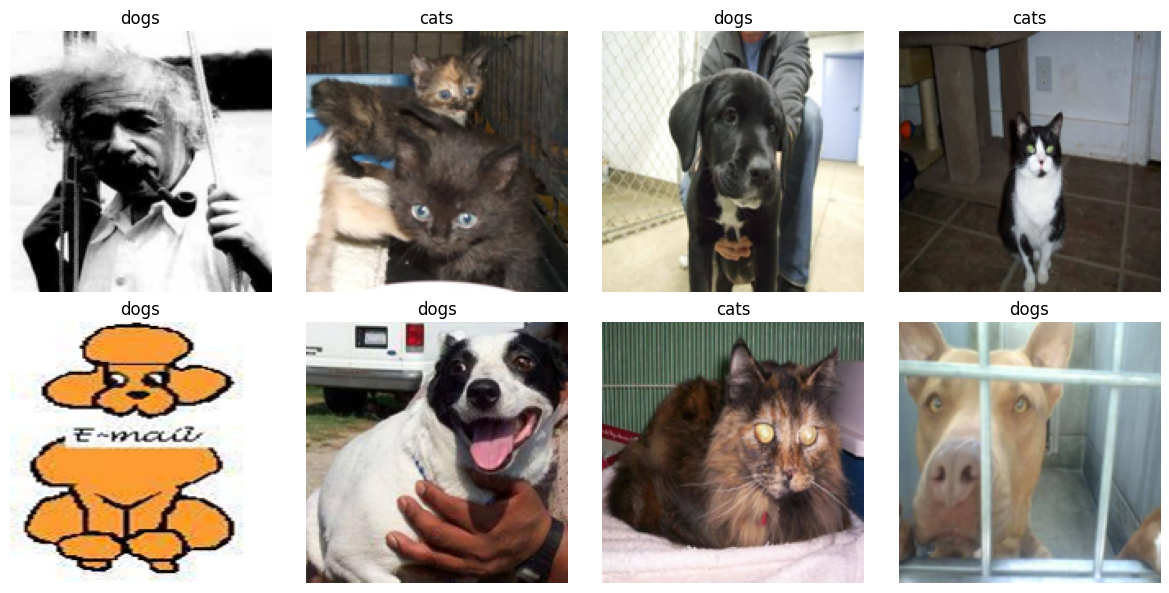

In [5]:
# Peek at 8 random training images
sample_idx = np.random.RandomState(42).choice(len(X_train), 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes.flat, sample_idx):
    ax.imshow(X_train[i].astype('uint8'))
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
plt.tight_layout(); plt.show()

## Phase 1 — Feature Extraction (frozen base)

Same idea as the flowers notebook: freeze MobileNetV2, train a fresh head. **Two deliberate differences:**

- **Augmentation lives inside the model from the start** (RandomFlip + RandomRotation). It's inactive at inference, and keeping it in the graph lets us reuse the *same* model object for Phase 2.
- **A modest learning rate (1e-4) for only 5 epochs.** We *want* Phase 1 to plateau around 96–97% rather than slam into the ceiling — that headroom is what makes Phase 2's benefit visible.

In [6]:
base_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = False

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
], name='augmentation')

inputs = keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)         # active only during training
x = preprocess_input(x)
x = base_model(x, training=False)     # BatchNorm stays in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = keras.Model(inputs, outputs, name='catsdogs_transfer')

BASE_LR = 1e-4
model.compile(
    optimizer=keras.optimizers.Adam(BASE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "catsdogs_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
P1_EPOCHS = 5
phase1_history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=P1_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)
phase1_acc = model.evaluate(X_val, y_val, verbose=0)[1]
print(f'\nPhase 1 (frozen) validation accuracy: {phase1_acc:.4f}')
# Expect ~96-97% — strong, but with a little headroom left for Phase 2.

Epoch 1/5
63/63 - 6s - 93ms/step - accuracy: 0.6060 - loss: 0.7354 - val_accuracy: 0.8510 - val_loss: 0.3919
Epoch 2/5
63/63 - 5s - 75ms/step - accuracy: 0.7850 - loss: 0.4661 - val_accuracy: 0.9210 - val_loss: 0.2463
Epoch 3/5
63/63 - 5s - 76ms/step - accuracy: 0.8495 - loss: 0.3512 - val_accuracy: 0.9490 - val_loss: 0.1820
Epoch 4/5
63/63 - 5s - 77ms/step - accuracy: 0.8905 - loss: 0.2824 - val_accuracy: 0.9620 - val_loss: 0.1475
Epoch 5/5
63/63 - 5s - 75ms/step - accuracy: 0.8970 - loss: 0.2539 - val_accuracy: 0.9680 - val_loss: 0.1286

Phase 1 (frozen) validation accuracy: 0.9680


## Phase 2 — Fine-Tuning (continue the *same* model)

Now the part that actually helps. We **do not rebuild** the model — we keep Phase 1's trained head and:

1. Unfreeze the **top of the base** (layers from index 100 on — the high-level, task-specific features). The early edge/texture layers stay frozen.
2. **Drop the learning rate 10× (1e-5).** This is critical. At the full rate, the large early gradients *destroy* the pretrained features — when we tested LR 1e-4 here, accuracy collapsed by ~10 points (catastrophic forgetting).
3. **Continue training** from where Phase 1 stopped (`initial_epoch`), so the head we just trained isn't thrown away.

In [8]:
# Unfreeze the top of the base; keep the bottom frozen
base_model.trainable = True
FINE_TUNE_AT = 100
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers: {trainable} of {len(base_model.layers)}')

# Recompile is REQUIRED after changing trainability — now at 10x lower LR
model.compile(
    optimizer=keras.optimizers.Adam(BASE_LR / 10),   # 1e-5
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

P2_EPOCHS = 15
phase2_history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=P1_EPOCHS + P2_EPOCHS,
    initial_epoch=P1_EPOCHS,          # continue, don't restart
    batch_size=BATCH_SIZE,
    verbose=2,
)
phase2_acc = model.evaluate(X_val, y_val, verbose=0)[1]
print(f'\nPhase 1 accuracy: {phase1_acc:.4f}')
print(f'Phase 2 accuracy: {phase2_acc:.4f}')
print(f'Improvement: {(phase2_acc - phase1_acc) * 100:+.2f} percentage points')

Trainable base layers: 54 of 154
Epoch 6/20
63/63 - 6s - 101ms/step - accuracy: 0.8080 - loss: 0.4109 - val_accuracy: 0.9810 - val_loss: 0.0879
Epoch 7/20
63/63 - 6s - 92ms/step - accuracy: 0.8860 - loss: 0.2651 - val_accuracy: 0.9810 - val_loss: 0.0735
Epoch 8/20
63/63 - 6s - 90ms/step - accuracy: 0.8980 - loss: 0.2294 - val_accuracy: 0.9830 - val_loss: 0.0662
Epoch 9/20
63/63 - 6s - 90ms/step - accuracy: 0.9300 - loss: 0.1840 - val_accuracy: 0.9850 - val_loss: 0.0604
Epoch 10/20
63/63 - 6s - 92ms/step - accuracy: 0.9290 - loss: 0.1793 - val_accuracy: 0.9860 - val_loss: 0.0569
Epoch 11/20
63/63 - 6s - 91ms/step - accuracy: 0.9345 - loss: 0.1662 - val_accuracy: 0.9870 - val_loss: 0.0548
Epoch 12/20
63/63 - 6s - 91ms/step - accuracy: 0.9340 - loss: 0.1707 - val_accuracy: 0.9870 - val_loss: 0.0526
Epoch 13/20
63/63 - 6s - 92ms/step - accuracy: 0.9460 - loss: 0.1451 - val_accuracy: 0.9880 - val_loss: 0.0531
Epoch 14/20
63/63 - 6s - 91ms/step - accuracy: 0.9480 - loss: 0.1359 - val_accurac

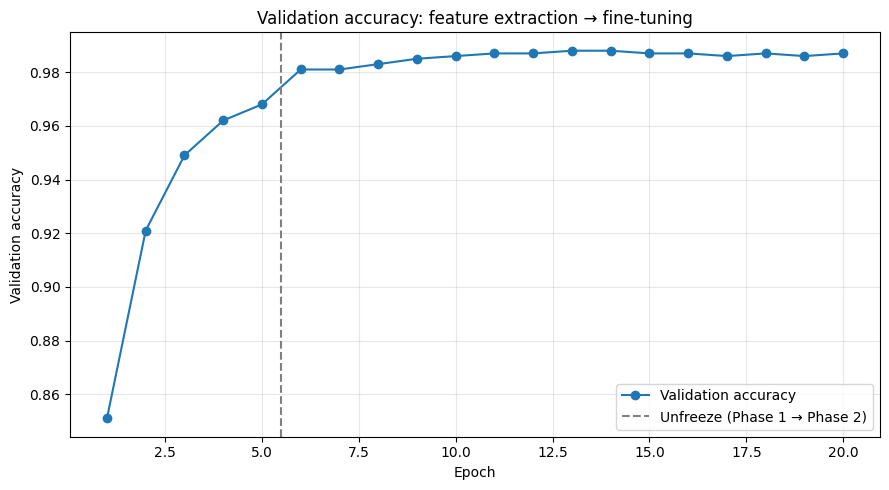

In [9]:
# Plot the validation curve across BOTH phases — look for the jump at the unfreeze line
val_acc = phase1_history.history['val_accuracy'] + phase2_history.history['val_accuracy']
epochs = range(1, len(val_acc) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, val_acc, '-o', label='Validation accuracy')
plt.axvline(P1_EPOCHS + 0.5, color='gray', linestyle='--', label='Unfreeze (Phase 1 → Phase 2)')
plt.title('Validation accuracy: feature extraction → fine-tuning')
plt.xlabel('Epoch'); plt.ylabel('Validation accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## What just happened — and the real lesson

You should see the validation curve **plateau** during Phase 1, then **jump and keep climbing** right after the unfreeze line — a gain of roughly **+2 percentage points**. On 1,000 validation images that's ~20 images: a real signal, not noise.

**Why it worked here but barely moved on flowers:**

| Dataset | Phase 1 (frozen) | Phase 2 (fine-tune) |
|---|---|---|
| Flowers — in-domain, ImageNet nails them | ~98% | ~98% (no room) |
| Cats vs dogs — headroom + enough data | ~97% | ~99% |

**The takeaways:**
1. **Feature extraction is a strong default.** When your data looks like ImageNet, frozen features may already be near-optimal — and fine-tuning has nothing to add.
2. **Fine-tuning helps when there's headroom *and* you do it carefully:** continue from the trained head, unfreeze only the top, use a low LR. We measured the failure modes too — too-high an LR (or letting BatchNorm chase a new domain) caused **catastrophic forgetting** (−10 to −24 pp).
3. **The size of the "win" depends on the baseline.** A fully-converged Phase 1 leaves nothing to gain; the textbook jump assumes a Phase 1 that still has room.

## Back to the live session

Return to `week9_live_session.ipynb`. The pattern is identical — frozen base, then fine-tune the top at a low LR — but now you've seen *both* sides:

- On easy / in-domain data, **feature extraction alone is enough.**
- On data with headroom, **fine-tuning adds a real (if modest) gain** — when the recipe respects the pretrained features.

Knowing *which* situation you're in — and therefore whether to bother fine-tuning — is the actual skill.